In [21]:
import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image
import os

In [22]:
def rgb_to_grayscale(image):
    """
    Convertit une image RGB en niveaux de gris.
    
    Parameters:
    image (numpy.ndarray): Image RGB à convertir.
    
    Returns:
    numpy.ndarray: Image en niveaux de gris.
    """
    # Vérifier si l'image est déjà en niveaux de gris
    if len(image.shape) == 2:
        return image
    
    # Utiliser la formule de luminosité pour convertir en niveaux de gris
    grayscale = 0.299 * image[:, :, 0] + 0.587 * image[:, :, 1] + 0.114 * image[:, :, 2]
    
    return grayscale.astype(np.float64)

In [74]:
img = np.asarray(Image.open("cell_images\Parasitized\C33P1thinF_IMG_20150619_114756a_cell_179.png"))
print(img.shape)


def load_images(uninfected, parasitized, image_size=(16,16), max_per_class=200):
    data = []
    target = []

    
    count = 0
    for filename in os.listdir(uninfected):
        if filename.endswith(".png"):
            path = uninfected + "/" + filename

            img = Image.open(path).convert("RGB")
            img = img.resize(image_size)
            arr = np.array(img) / 255.0
            arr_gray = rgb_to_grayscale(arr)

            data.append(arr_gray.flatten())
            target.append(0)
            count += 1
            if count == max_per_class:
                break

    count = 0
    for filename in os.listdir(parasitized):
        if filename.endswith(".png"):
            path = parasitized + "/" + filename

            img = Image.open(path).convert("RGB")
            img = img.resize(image_size)
            arr = np.array(img) / 255.0
            arr_gray = rgb_to_grayscale(arr)

            data.append(arr_gray.flatten())
            target.append(1)

            count += 1
            if count == max_per_class:
                break

    return np.array(data), np.array(target)


data, target = load_images(
    "cell_images/Uninfected",
    "cell_images/Parasitized"
)

data = np.asarray(data)
target = np.asarray(target)

print(data)
print(data.shape)
print(data.min())
print(data.max())
print(data.mean())

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Capucine\AppData\Local\Temp\ipykernel_15420\4223836202.py:1: SyntaxWarning: invalid escape sequence '\P'
  img = np.asarray(Image.open("cell_images\Parasitized\C33P1thinF_IMG_20150619_114756a_cell_179.png"))


(163, 142, 3)
[[0.         0.         0.11270588 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
(400, 256)
0.0
0.8472549019607842
0.4586086536841299


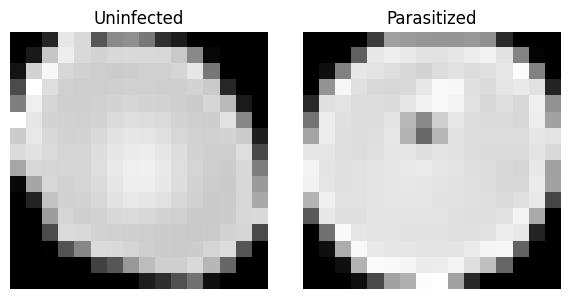

In [76]:
plt.figure(figsize=(6, 3))

# image classe 0 : Uninfected
plt.subplot(1, 2, 1)
plt.imshow(data[target == 0][0].reshape(16, 16), cmap="gray")
plt.title("Uninfected")
plt.axis("off")

# image classe 1 : Parasitized
plt.subplot(1, 2, 2)
plt.imshow(data[target == 1][0].reshape(16, 16), cmap="gray")
plt.title("Parasitized")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:


def sigmoid(z):
    return 1/(1 + np.exp(-z))


def eval_forward(x, w, b, verb=0):
    """
    Evaluate a MLP on an input vector.
    Args:
        x: Input vector.
        w: List containing for each layer its matrix of weights.
        b: List containing for each layer its vector of biases.
        verb: verbosity. Default 0, no message.
    """

    L = len(w) - 1
    a = [np.copy(x)] # layer 0 is the input vector


    for l in range(1,L+1):
        z_l = np.matmul(w[l], a[l-1]) + b[l]
        a_l = sigmoid(z_l)
        a.append(a_l)
            
    return a


def init_parameters(n_feats, hidden_layer_sizes, rng=None):
    """
    Random initialization of weights and biases.
    Args:
        n_feats: Number of features (i.e., size of layer 0).
        hidden_layer_sizes: List of the sizes of each of the hidden layers.
        rng: Random generator if any.
    Returns:
        Lists of weights and biases initialized of each layer.
        """
    
    if rng is None:
        rng = np.random.default_rng()

    L = 1 + len(hidden_layer_sizes)
    # Initialization of parameters for layer 0 (input layer) as an empty matrix
    # and an empty vector since there is no weight and bias associated to this layer.
    w = [np.zeros((0,0))]
    b = [np.zeros(0)]

    # Initialization of parameters for layer 1, i.e., first hidden layer
    # that takes values from all features of the input layer.
    # Biases are initialized to zero. Weights are picked at random
    # in [-0.5; 0.5[ in a uniform way.
    w.append(rng.normal(0,np.sqrt(2 / n_feats),(hidden_layer_sizes[0], n_feats)))
    b.append(np.zeros((hidden_layer_sizes[0])))
    
    # Initialization of parameters for layers 2 to L-1.
    for l in range(2, L):
        fan_in = hidden_layer_sizes[l-2]
        w.append(rng.normal(0,np.sqrt(2 / fan_in),(hidden_layer_sizes[l-1], fan_in)))
        b.append(np.zeros((hidden_layer_sizes[l-1])))

    # Initialization of parameters for layer L (output layer)
    fan_in = hidden_layer_sizes[L-2]

    w.append(rng.normal(0,np.sqrt(2 / fan_in),(1, fan_in)))
    b.append(np.zeros((1)))

    return w, b


def mlp_error(data, target, w, b):
    E = 0
    for x in range(len(data)):
        a=eval_forward(data[x],w,b)
        pred = a [-1]
        e = np.sum((target[x]-pred)**2)
        E+=e
    return E


def mlp_fit(data, target, n_epochs=10, hidden_layer_sizes=[3,2], learning_rate=0.2,
            random_state=None, verb=0):
    
    if random_state != None:
        rng = np.random.default_rng(random_state)
    else:
        rng = np.random.default_rng()

    n_objs, n_feats = data.shape
    L = len(hidden_layer_sizes) + 1

    w, b = init_parameters(n_feats, hidden_layer_sizes, rng)
    

    for epoch in range(n_epochs):
        err = [None] * (L+1)
        for x in range(n_objs) :
            #prediction
            a = eval_forward(data[x],w,b)
            #erreur en sortie
            da_output = a[-1]*(1-a[-1])
            err[-1] = 2*(a[-1]-target[x])*da_output
                
            #Backpropagation in hidden layers 
            for l in range(L-1,0,-1):
                da = a[l]*(1-a[l])
                err_next = err[l+1]
                err_l = np.matmul(w[l+1].T, err_next)*da
                err[l] = err_l
            
            #mettre à jour le poids et les biais 
            for l in range(1, L+1):
                dw = np.outer(err[l], a[l-1])
                w[l] -= learning_rate * dw
                b[l] -= learning_rate * err[l]

    # end for epoch
    
    return w, b



In [33]:
def predict_proba(x, w, b):
    a = eval_forward(x, w, b)
    return a[-1][0]


def predict(x, w, b):
    proba = predict_proba(x, w, b)

    if proba >= 0.5:
        return 1
    else:
        return 0

In [50]:
indices = np.arange(len(data))
np.random.seed(42) #pour la reproductibilité
np.random.shuffle(indices)

n_splits = 5

folds = np.array_split(indices, n_splits)

accuracies = []

for k in range(n_splits):

    print(f"\n===== Fold {k+1} =====")

    # fold de test
    test_idx = folds[k]

    # folds d'entraînement
    train_idx = np.concatenate(
        [folds[i] for i in range(n_splits) if i != k]
    )

    # séparation des données
    X_train = data[train_idx]
    y_train = target[train_idx]

    X_test = data[test_idx]
    y_test = target[test_idx]

    # entraînement
    w, b = mlp_fit(
        X_train,
        y_train,
        n_epochs=100,
        hidden_layer_sizes=[16, 8],
        learning_rate=0.1,
        random_state=42
    )

    # test
    correct = 0

    for i in range(len(X_test)):
        pred = predict(X_test[i], w, b)

        if pred == y_test[i]:
            correct += 1

    accuracy = correct / len(X_test)

    print("Accuracy :", accuracy)

    accuracies.append(accuracy)

print("\nAccuracy moyenne :", np.mean(accuracies))
print(X_train.shape)
print(X_test.shape)


===== Fold 1 =====
Accuracy : 0.5875

===== Fold 2 =====
Accuracy : 0.5875

===== Fold 3 =====
Accuracy : 0.525

===== Fold 4 =====
Accuracy : 0.475

===== Fold 5 =====
Accuracy : 0.5125

Accuracy moyenne : 0.5375
(320, 4096)
(80, 4096)


In [ ]:
def relu(z):
    return np.maximum(0,z)

def mlp_error_relu(data, target, w, b):
    E = 0
    for x in range(len(data)):
        a=eval_forward_relu(data[x],w,b)
        pred = a [-1]
        e = np.sum((target[x]-pred)**2)
        E+=e
    return E

def eval_forward_relu(x, w, b, verb=0):
    """
    Evaluate a MLP on an input vector.
    Args:
        x: Input vector.
        w: List containing for each layer its matrix of weights.
        b: List containing for each layer its vector of biases.
        verb: verbosity. Default 0, no message.
    """

    L = len(w) - 1
    a = [np.copy(x)] # layer 0 is the input vector


    for l in range(1,L+1):
        z_l = np.matmul(w[l], a[l-1]) + b[l]

        if l == L :
            a_l = sigmoid(z_l)   # sortie
        else :
            a_l = relu(z_l)
        
        a.append(a_l)
            
    return a


def mlp_fit_relu(data, target, n_epochs=10, hidden_layer_sizes=[3,2], learning_rate=0.2,
            random_state=None, verb=0):
    
    if random_state != None:
        rng = np.random.default_rng(random_state)
    else:
        rng = np.random.default_rng()

    n_objs, n_feats = data.shape
    L = len(hidden_layer_sizes) + 1
    

    w, b = init_parameters(n_feats, hidden_layer_sizes, rng)
    losses = []
   

    for epoch in range(n_epochs):
        err = [None] * (L+1)
        for x in range(n_objs) :
            #prediction
            a = eval_forward_relu(data[x],w,b)
            #erreur en sortie
            da_output = a[-1] * (1 - a[-1])
            err[-1] = 2*(a[-1]-target[x])*da_output
                
            #Backpropagation in hidden layers 
            for l in range(L-1,0,-1):
                da = (a[l]>0).astype(float)
                err_next = err[l+1]
                err_l = np.matmul(w[l+1].T, err_next)*da
                err[l] = err_l
            
            #mettre à jour le poids et les biais 
            for l in range(1, L+1):
                dw = np.outer(err[l], a[l-1])
                w[l] -= learning_rate * dw
                b[l] -= learning_rate * err[l]

        loss = mlp_error(data, target, w, b)
        losses.append(loss)
                            
            
                     
        

    # end for epoch
    
    return w, b, losses



In [86]:
def predict_proba_relu(x, w, b):
    a = eval_forward_relu(x, w, b)
    return a[-1][0]

def predict_relu(x, w, b):
    proba = predict_proba_relu(x, w, b)

    if proba >= 0.5:
        return 1
    else:
        return 0
    
indices = np.arange(len(data))
np.random.seed(42)
np.random.shuffle(indices)

n_splits = 5

folds = np.array_split(indices, n_splits)

accuracies = []

for k in range(n_splits):

    print(f"\n===== Fold {k+1} =====")

    # fold de test
    test_idx = folds[k]

    # folds d'entraînement
    train_idx = np.concatenate(
        [folds[i] for i in range(n_splits) if i != k]
    )

    # séparation des données
    X_train = data[train_idx]
    y_train = target[train_idx]

    X_test = data[test_idx]
    y_test = target[test_idx]

    # entraînement
    w, b, losses = mlp_fit_relu(
        X_train,
        y_train,
        n_epochs=100,
        hidden_layer_sizes=[32, 16],
        learning_rate=0.001,
        random_state=42
    )

    # test
    correct = 0

    for i in range(len(X_test)):
        pred = predict_relu(X_test[i], w, b)

        if pred == y_test[i]:
            correct += 1

    accuracy = correct / len(X_test)

    print("Accuracy :", accuracy)

    accuracies.append(accuracy)

print("\nAccuracy moyenne :", np.mean(accuracies))
print(X_train.shape)
print(X_test.shape)


===== Fold 1 =====
Accuracy : 0.5875

===== Fold 2 =====
Accuracy : 0.625

===== Fold 3 =====
Accuracy : 0.6

===== Fold 4 =====
Accuracy : 0.6

===== Fold 5 =====
Accuracy : 0.6125

Accuracy moyenne : 0.6050000000000001
(320, 256)
(80, 256)


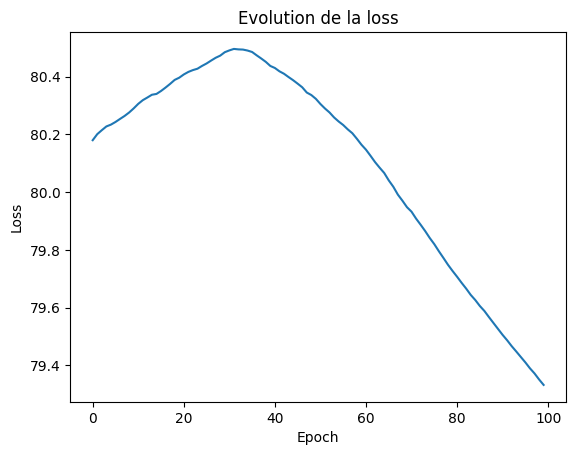

In [87]:
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolution de la loss")

plt.show()

In [ ]:
def mlp_error_entropy(data, target, w, b):
    '''Binary Cross Entropy'''
    E = 0
    epsilon = 1e-15
    
    for x in range(len(data)):
        a = eval_forward_relu(data[x], w, b)
        pred = a[-1][0]
        pred = np.clip(pred, epsilon, 1 - epsilon)
        y = target[x]
        e = - (y * np.log(pred) + (1-y) * np.log(1-pred))
        E += e

    return E


def mlp_fit_bce(data, target, n_epochs=10, hidden_layer_sizes=[3,2], learning_rate=0.001,
            random_state=None, verb=0):
    
    if random_state != None:
        rng = np.random.default_rng(random_state)
    else:
        rng = np.random.default_rng()

    n_objs, n_feats = data.shape
    L = len(hidden_layer_sizes) + 1
    

    w, b = init_parameters(n_feats, hidden_layer_sizes, rng)
    losses = []
    
  

    for epoch in range(n_epochs):
        err = [None] * (L+1)
        for x in range(n_objs) :
            #prediction
            a = eval_forward_relu(data[x],w,b)
            #erreur en sortie
            err[-1] = a[-1] - target[x]
                
            #Backpropagation in hidden layers 
            for l in range(L-1,0,-1):
                da = (a[l]>0).astype(float)
                err_next = err[l+1]
                err_l = np.matmul(w[l+1].T, err_next)*da
                err[l] = err_l
            
            #mettre à jour le poids et les biais 
            for l in range(1, L+1):
                dw = np.outer(err[l], a[l-1])
                w[l] -= learning_rate * dw
                b[l] -= learning_rate * err[l]
        
        loss = mlp_error_entropy(data, target, w, b)
        losses.append(loss)
                            
            
                     
        

    # end for epoch
    
    return w, b, losses


In [79]:
indices = np.arange(len(data))
np.random.seed(42)
np.random.shuffle(indices)

n_splits = 5

folds = np.array_split(indices, n_splits)

accuracies = []

for k in range(n_splits):

    print(f"\n===== Fold {k+1} =====")

    # fold de test
    test_idx = folds[k]

    # folds d'entraînement
    train_idx = np.concatenate(
        [folds[i] for i in range(n_splits) if i != k]
    )

    # séparation des données
    X_train = data[train_idx]
    y_train = target[train_idx]

    X_test = data[test_idx]
    y_test = target[test_idx]

    # entraînement
    w, b, losses = mlp_fit_bce(
        X_train,
        y_train,
        n_epochs=500,
        hidden_layer_sizes=[32, 16],
        learning_rate=0.001,
        random_state=42
    )

    # test
    correct = 0

    for i in range(len(X_test)):
        pred = predict_relu(X_test[i], w, b)

        if pred == y_test[i]:
            correct += 1

    accuracy = correct / len(X_test)

    print("Accuracy :", accuracy)

    accuracies.append(accuracy)

print("\nAccuracy moyenne :", np.mean(accuracies))
print(X_train.shape)
print(X_test.shape)


===== Fold 1 =====
Accuracy : 0.675

===== Fold 2 =====
Accuracy : 0.725

===== Fold 3 =====
Accuracy : 0.6875

===== Fold 4 =====
Accuracy : 0.65

===== Fold 5 =====
Accuracy : 0.6375

Accuracy moyenne : 0.675
(320, 256)
(80, 256)


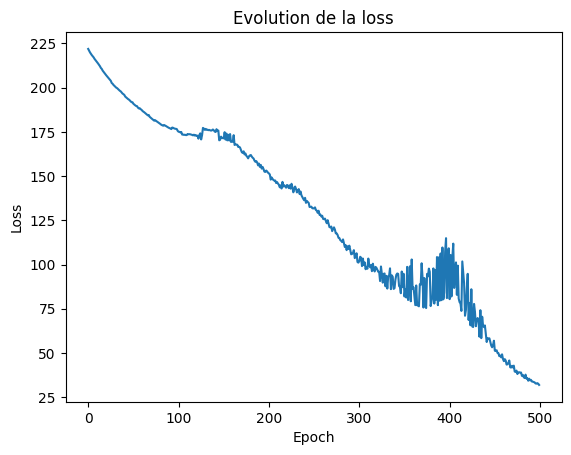

In [80]:
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolution de la loss")

plt.show()